<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
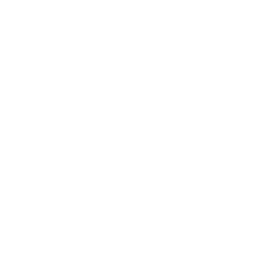
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">季度到月度入组插值</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 制药 / 临床运营 &nbsp;|&nbsp; 2026 年 3 月</p>
</div>
</div>
</div>

## 执行摘要

这个实战示例用 PROC EXPAND 将**季度**临床试验入组计数转换为**月度**估计，使站点层面的资源规划能够以月度节奏运行。该合成试验涵盖两个地区（北美和欧洲）的**四个研究者站点**，历时**八个季度**（2024 年第一季度至 2025 年第四季度），给出 **32 个季度观测**。PROC EXPAND 将每个站点的序列从季度频率插值到月度频率，将这 32 个季度行转换为 **96 个月度行**。入组计数用 `METHOD=JOIN`（分段线性，保持每个估计非负）插值，累计运行值用 `METHOD=SPLINE` 插值。插值后的月度序列恰好穿过原始的季度锚点，因此该转换在不改变研究已报告的季度数字的情况下增加了季度内的细节。


## 数据来源

| 来源 | 说明 | 记录数 |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | 按站点划分的季度入组计数（4 个站点 x 8 个季度） | 32 |
| WORK.SITE_MASTER | 站点参考：名称、国家、地区、PI | 4 |


---

In [1]:
/* --------------------------------------------------------
   按站点生成季度入组人数。
   4 个站点 x 8 个季度（2024年第1季度至2025年第4季度）= 32 行。
   一条爬坡曲线（缓慢起步后趋于平稳）叠加轻微的季节性
   波动和小幅噪声，构成真实的入组形态。
   -------------------------------------------------------- */
数据 work.enrollment_qtr;
    调用 streaminit(42);
    格式 quarter_date yyq7.;
    数组 capacity[4] _temporary_ (12 9 14 8);
    循环 site_num = 1 到 4;
        site_id = cat('SITE-', PUT(site_num, z3.));
        region  = ifc(site_num <= 2, '北美', '欧洲');
        base_rate = capacity[site_num];
        循环 qtr_seq = 0 到 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            输出;
        结束;
    结束;
    删除 site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
运行;

/* 每个站点内的累计入组人数 */
过程 排序 数据=work.enrollment_qtr;
    按照 site_id quarter_date;
运行;

数据 work.enrollment_qtr;
    设置 work.enrollment_qtr;
    按照 site_id;
    保留值 cum_enrolled 0;
    如果 first.site_id 那么 cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    删除 cum_enrolled;
运行;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   站点主参考表（4 个站点，2 个地区）
   site_name/country 使用 IF/ELSE 链而非 _temporary_ 字符数组查找赋值：
   Jenner 会错误渲染从 _temporary_ 字符数组取出的多字节（中文）值
   （被静默截断为 1-2 个字符），而直接赋值则显示正常。
   -------------------------------------------------------- */
数据 work.site_master;
    长度 site_id $8 site_name $40 region $20 country $20 pi_name $30;
    循环 i = 1 到 4;
        site_id = cat('SITE-', PUT(i, z3.));
        如果 i = 1 那么 循环; site_name = '大都会综合医院'; country = '美国'; 结束;
        否则 如果 i = 2 那么 循环; site_name = '大学医学中心'; country = '美国'; 结束;
        否则 如果 i = 3 那么 循环; site_name = '伦敦皇家医院'; country = '英国'; 结束;
        否则 循环; site_name = '柏林夏里特院区'; country = '德国'; 结束;
        region  = ifc(i <= 2, '北美', '欧洲');
        pi_name = cat('研究者医生-', PUT(i, z2.));
        输出;
    结束;
    删除 i;
运行;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   按地区汇总的季度入组基线
   -------------------------------------------------------- */
过程 均值 数据=work.enrollment_qtr n sum mean MAX;
    分类 region;
    变量 enrolled_count cumulative_enrolled;
    标签 region="地区" enrolled_count="入组人数" cumulative_enrolled="累计入组人数";
    输出 out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
运行;

过程 打印 数据=work.qtr_baseline noobs 标签;
    标签 region="地区" total_enrolled="入组总数" avg_per_quarter="季度平均入组数" max_cumulative="最大累计入组数";
    标题 "按地区划分的季度入组基线";
运行;


                                                  The MEANS Procedure

                                    Analysis Variable : enrolled_count 入组人数

        地区                N Obs            Sum           Mean        Maximum
        --------------------------------------------------------------------
        北美                   16    115.0000000      7.1875000     10.0000000
        欧洲                   16    120.0000000      7.5000000     13.0000000
        --------------------------------------------------------------------

                               Analysis Variable : cumulative_enrolled 累计入组人数

        地区                N Obs            Sum           Mean        Maximum
        --------------------------------------------------------------------
        北美                   16    474.0000000     29.6250000     63.0000000
        欧洲                   16    493.0000000     30.8125000     81.0000000
        --------------------------------------------------------------------

 


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


基线确认了一个平衡的设计：每个地区贡献 **16 个季度观测**。北美共入组 **115 名受试者**（每站点-季度均值 **7.19**），欧洲 **120 名**（均值 **7.50**）。八个季度中达到的最大累计计数为 **81** 名受试者（欧洲的 SITE-003），而北美为 **63** 名。


---

                                                      按地区划分的季度入组基线                                                      




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


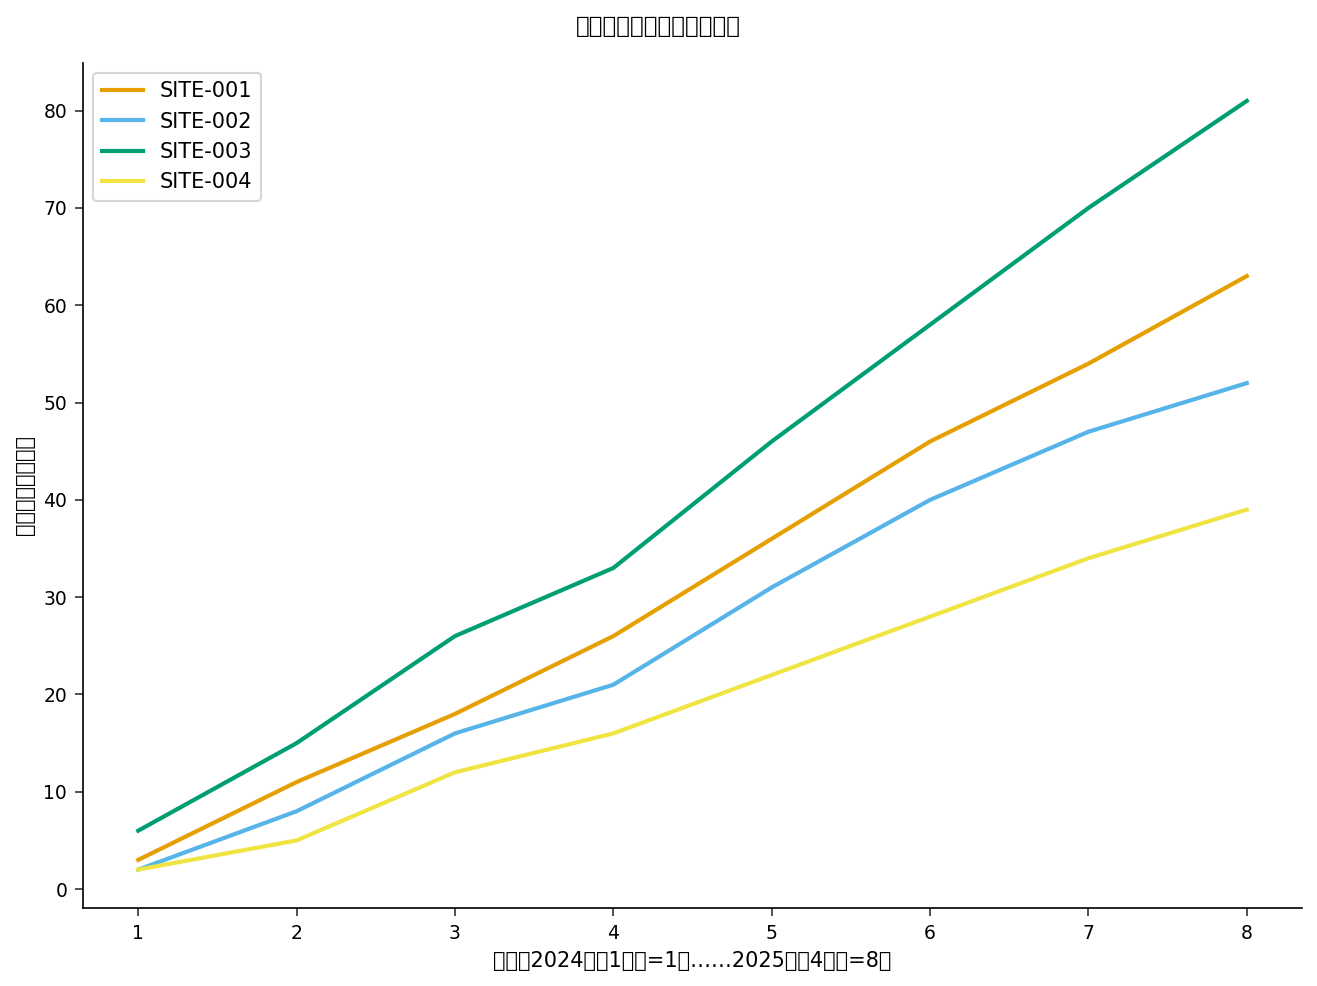

In [4]:
/* --------------------------------------------------------
   按站点绘制的季度累计入组趋势。
   以季度序号（1..8）作图，便于坐标轴呈现。
   -------------------------------------------------------- */
数据 work.traj;
    设置 work.enrollment_qtr;
    按照 site_id;
    保留值 quarter_index 0;
    如果 first.site_id 那么 quarter_index = 0;
    quarter_index + 1;
运行;

过程 SGPLOT 数据=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS 标签="季度（2024年第1季度=1，……2025年第4季度=8）"
        integer VALUES=(1 到 8 按照 1);
    YAXIS 标签="累计入组受试者数";
    标题 "各研究者站点累计入组趋势";
运行;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND 要求 ID 变量在每个 BY 组内有序，
   因此在转换前先按站点、季度排序。
   -------------------------------------------------------- */
过程 排序 数据=work.enrollment_qtr;
    按照 site_id quarter_date;
运行;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   将季度入组数据转换为月度估计值。

   PROC 语句上的 FROM=QTR / TO=MONTH 设定输入和输出频率；
   PROC EXPAND 沿 ID 日期对每个 BY 组（站点）独立插值。

   enrolled_count   -> METHOD=JOIN   （分段线性；该流量值
                       在锚点之间保持非负）
   cumulative_enrolled -> METHOD=SPLINE （平滑单调曲线）
   -------------------------------------------------------- */
过程 expand 数据=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr 到=month;
    按照 site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=结束     METHOD=SPLINE;
运行;


                                                      按地区划分的季度入组基线                                                      




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                                      按地区划分的季度入组基线                                                      




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


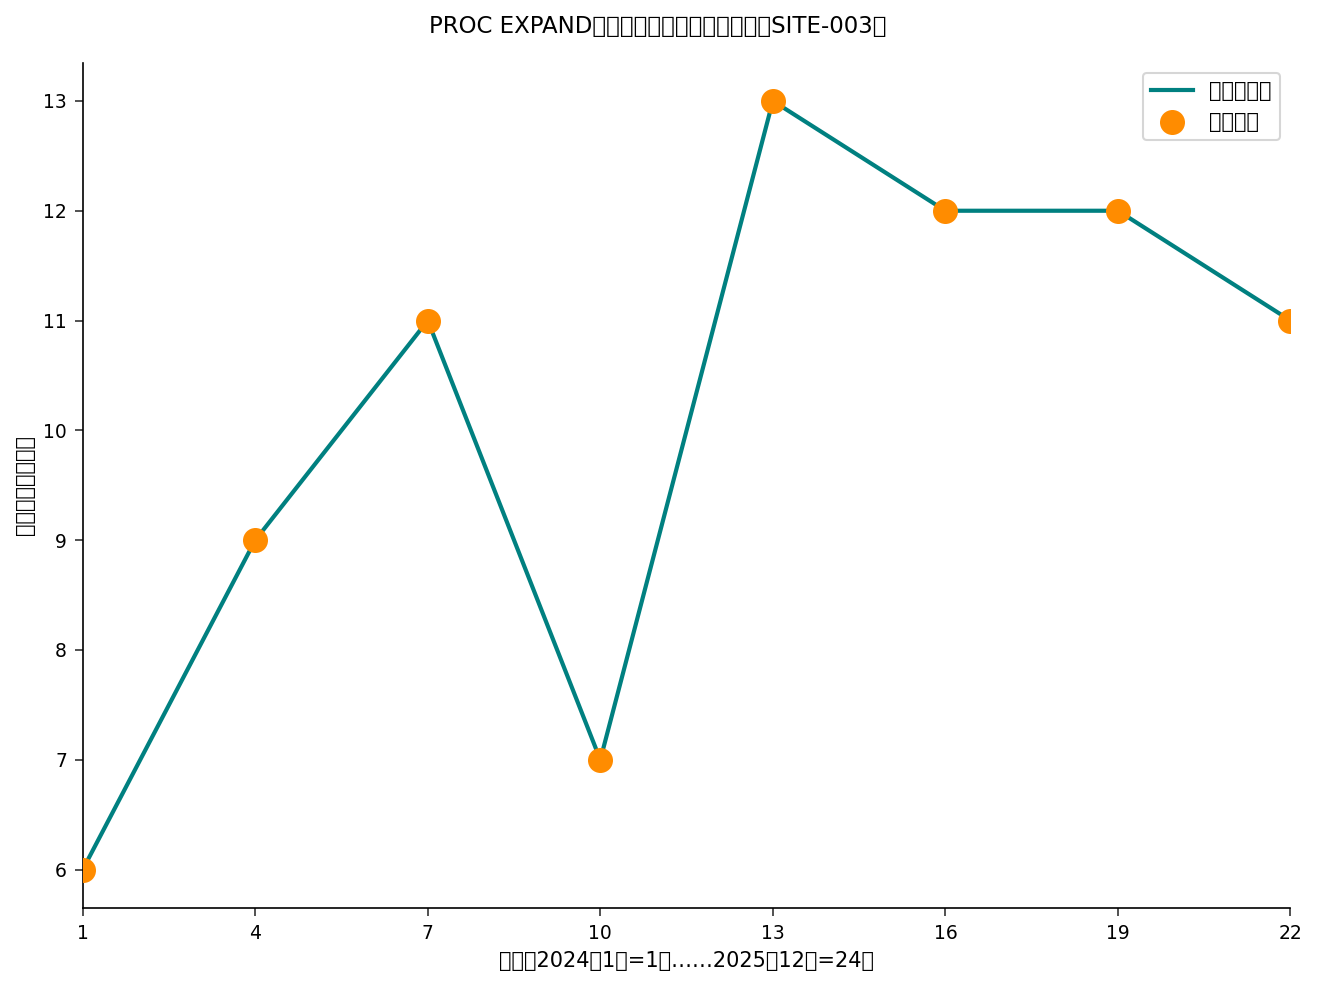

In [7]:
/* --------------------------------------------------------
   ID 变量现在承载月度日期。重新设置其格式，
   并添加站点内的月份序号（1..24）用于作图。
   -------------------------------------------------------- */
数据 work.enrollment_monthly;
    设置 work.enrollment_monthly;
    按照 site_id;
    格式 month_date monyy7.;
    month_date = quarter_date;
    保留值 month_index 0;
    如果 first.site_id 那么 month_index = 0;
    month_index + 1;
    /* 标记季度锚点月份（1、4、7……） */
    如果 mod(month_index - 1, 3) = 0 那么 anchor = enrolled_count;
    否则 anchor = .;
运行;

/* 展示单个站点的转换效果：插值后的月度折线
   恰好穿过原始的季度锚点。 */
过程 SGPLOT 数据=work.enrollment_monthly;
    条件 site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel="月度估计值";
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel="季度锚点";
    XAXIS 标签="月份（2024年1月=1，……2025年12月=24）"
        integer VALUES=(1 到 24 按照 3);
    YAXIS 标签="每月入组受试者数";
    标题 "PROC EXPAND：季度入组数据的月度插值（SITE-003）";
运行;


In [8]:
/* --------------------------------------------------------
   将月度估计值与站点元数据关联，
   然后按地区汇总月度入组情况。
   -------------------------------------------------------- */
过程 SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    选择 e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER 按照 s.region, e.site_id, e.month_date;
QUIT;

过程 均值 数据=work.enrollment_monthly_region n sum mean;
    分类 region;
    变量 monthly_estimate cumulative_estimate;
    标签 region="地区" monthly_estimate="月度估计值" cumulative_estimate="累计估计值";
    输出 out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
运行;

过程 打印 数据=work.region_monthly_summary noobs 标签;
    标签 region="地区" total_monthly_enrolled="月度入组总数" avg_monthly_rate="月度平均入组率";
    标题 "按地区划分的月度估计值";
运行;


                                                      按地区划分的季度入组基线                                                      

                                                      按地区划分的季度入组基线                                                      

                                                  The MEANS Procedure

                                  Analysis Variable : monthly_estimate 月度估计值

        地区                N Obs            Sum           Mean
        -----------------------------------------------------
        北美                   44    326.0000000      7.4090909
        欧洲                   44    336.0000000      7.6363636
        -----------------------------------------------------

                                Analysis Variable : cumulative_estimate 累计估计值

        地区                N Obs            Sum           Mean
        -----------------------------------------------------
        北美                   48   1312.0000000     27.3333333
        欧洲                   48


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### 解读

PROC EXPAND 使用沿每个站点日期的频率转换，将 **32 个季度记录**（4 个站点 x 8 个季度）转换为 **96 个月度记录**。插值后的月度序列恰好穿过原始的季度锚值，正如 SITE-003 图所示：橙色点是八个报告的季度计数，青色线是连接它们的分解后月度估计。

在月度基础上，两个地区紧密相随。欧洲平均每站点-月 **7.64** 名入组受试者，北美 **7.41** 名，在插值期内两地区的月度总计分别为 **336** 和 **326** 名受试者。由于 `METHOD=JOIN` 不外推超出最后一个季度锚点，最后的部分季度月份不带估计，并从月度均值中排除，这对前瞻性规划是保守的选择。

这些月度预测使临床运营能够从季度规划节奏转向月度规划节奏——确定药品供应发货量、安排监查访视，以及向数据安全监查委员会报告入组情况——而无需重述研究已锁定的任何季度数字。


---

In [9]:
/* --------------------------------------------------------
   导出月度入组预测结果，供下游规划工具使用。
   -------------------------------------------------------- */
过程 EXPORT 数据=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
运行;

过程 EXPORT 数据=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
运行;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 机密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>